# Laboratorio 4 — Parte II: Modelos de Machine Learning sobre datos geoespaciales
## CC3084 Data Science — UVG — Semestre II 2026

**Commit 3/3 — Ejercicios 1, 2 y 3 (avance completo)** · Rama: `avance-lab4-parte2` · Entrega (avance): 23 de agosto de 2026, 23:59

| Campo | Valor |
|---|---|
| Integrantes | Jose Javier Valladares · Hugo Javier Cifuentes Carredano (23079) · Ian Cumes (23236) |
| Contenido | Ejercicios 1, 2 y 3 de la Parte II: preparación del dataset de Machine Learning, construcción de la variable respuesta y selección de variables predictoras |
| Repositorio | https://github.com/iancumes/Lab4DataScience |

En la **Parte I** de este laboratorio se descargaron 22 escenas Sentinel-2 (11 fechas
por lago) para Atitlán y Amatitlán, y se calcularon por píxel: NDVI, NDWI y un proxy
de cianobacteria (`chlorophyll_a`, en mg/m³, numéricamente equivalente a µg/L) a
partir del script oficial *Cyano Detection* de Sentinel Hub. Todo quedó persistido en
`data/processed/<lago>/<fecha>/` como rásters (`ndvi.tif`, `ndwi.tif`,
`cyanobacteria.tif`, `masks.tif`) alineados a la misma grilla de 20 m en
**EPSG:32615 (WGS 84 / UTM zona 15N)**.

En esta **Parte II** el enunciado pide construir, a partir de esos datos, un dataset
tabular apto para Machine Learning y modelos capaces de identificar zonas con alta
presencia de cianobacteria. Este notebook resuelve los **Ejercicios 1, 2 y 3** — el avance completo que se entrega en esta fecha; el modelado, la validación espacial, la generalización entre lagos, la interpretabilidad y las conclusiones (Ejercicios 4 a 10) se entregan en la versión final. Todo el código reutilizable vive en
`src/ml_dataset.py`; aquí se llama a esas funciones y se documenta cada decisión y
resultado.

## 0. Preparación del entorno

Igual que en la Parte I, el pipeline vive en el paquete `src/` del repositorio
(versionado en GitHub). Este notebook se ejecuta desde `src/`, así que agregamos la
raíz del repo al `sys.path` para poder importarlo como paquete.

In [1]:
import sys, os
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from IPython.display import display

from src.config import LAKES, PROCESSED_DIR, OUTPUTS_DIR, expected_dates
from src.ml_dataset import (
    build_pixel_dataset,
    dataset_summary,
    add_response_variable,
    engineer_features,
    lake_centroids_utm,
    save_ready_dataset,
    RESPONSE_COLUMN,
    RESPONSE_LEAKAGE_COLUMNS,
    WHO_ALERT_LEVEL_1_UG_L,
)

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
LAKE_COLORS = {"amatitlan": "#c0392b", "atitlan": "#2471a3"}
LAKE_LABELS = {"amatitlan": "Amatitlán", "atitlan": "Atitlán"}

print("Repositorio:", ROOT)
print("Lagos configurados:", list(LAKES.keys()))

Repositorio: C:\Users\ianro\OneDrive\Documentos\Uvg\Octavo Semestre\Data Science\Lab4DataScience
Lagos configurados: ['amatitlan', 'atitlan']


## 1. Ejercicio 1 — Preparación de los datos para Machine Learning

### 1.1–1.3. Construcción del dataset y eliminación de observaciones inválidas

Cada fila del dataset representa **un píxel válido de un lago en una fecha**. Se
construye aplanando, para cada una de las 22 combinaciones lago/fecha de la Parte I,
los rásters `ndvi.tif`, `ndwi.tif` y `cyanobacteria.tif` a lo largo de la grilla
común de 20 m, y quedándonos únicamente con los píxeles donde **simultáneamente**:

1. el píxel pertenece al polígono OSM del lago (`lake_polygon`, banda 1 de `masks.tif`);
2. el script oficial de Cyano Detection lo clasifica como **agua** (banda 4 de
   `masks.tif`, `official_script_water_mask`) — esto excluye orilla, vegetación
   flotante, suelo expuesto y zonas urbanas dentro del *bounding box*;
3. NDVI, NDWI y el proxy de cianobacteria son valores finitos (no NoData).

El punto 3 ya incorpora, heredado de la Parte I, la exclusión de nubes/sombras (SCL
de Sentinel-2 L2A: clases 0, 1, 3, 7, 8, 9, 10, 11), de píxeles sin cobertura de la
escena, y de valores del modelo de cianobacteria fuera de rango físico (0–500 mg/m³).
Es decir: si un píxel no pasó todos esos filtros en la Parte I, su valor ya quedó
escrito como NoData en el ráster y este notebook lo descarta automáticamente al
verificar que las tres bandas sean finitas. No se aplican filtros adicionales porque
haría el criterio de "válido" inconsistente con las estadísticas ya auditadas de la
Parte I (columna `valid_pixels` de `outputs/quality_metrics.csv`).

**Columnas mínimas incluidas:** coordenadas (`x_utm15n`, `y_utm15n` en EPSG:32615, y
`lon`/`lat` en WGS84 para visualización), `date`, `lake`, y los índices espectrales
`ndvi`, `ndwi`, `cyano_mg_m3` (proxy de presencia de cianobacteria).

**Nota sobre "bandas espectrales disponibles":** la Parte I *leyó* las 9 bandas TOA de
Sentinel-2 (`B02, B03, B04, B05, B07, B08, B8A, B11, B12`) para calcular NDVI, NDWI y
el índice de cianobacteria, pero **no las persistió individualmente** en
`data/processed/` (solo se escribieron los productos derivados, para mantener el
repositorio liviano y no depender de acceso a internet para reproducir el análisis).
Por lo tanto, para esta Parte II usamos como "bandas espectrales disponibles" los tres
índices ya calculados (NDVI, NDWI y el proxy de cianobacteria), documentado aquí
como decisión explícita (ver 1.6).

In [2]:
df_pixels = build_pixel_dataset(force=True)
print(f"Filas (observaciones = píxeles válidos): {len(df_pixels):,}")
df_pixels.head()

Filas (observaciones = píxeles válidos): 2,796,957


,lake,date,x_utm15n,y_utm15n,lon,lat,ndvi,ndwi,cyano_mg_m3
0,amatitlan,2025-01-28,757690.0,1603390.0,-90.609223,14.491131,0.000000,0.181387,4.672294
1,amatitlan,2025-01-28,757710.0,1603390.0,-90.609037,14.491130,0.030928,0.158878,4.861514
2,amatitlan,2025-01-28,757750.0,1603390.0,-90.608667,14.491126,0.012658,0.165877,4.681990
3,amatitlan,2025-01-28,757770.0,1603390.0,-90.608481,14.491124,-0.014599,0.194831,4.340311
4,amatitlan,2025-01-28,757630.0,1603370.0,-90.609781,14.490956,-0.062500,0.256198,4.611503


### 1.4. Número de observaciones, variables y valores faltantes

In [3]:
summary = dataset_summary(df_pixels)

print(f"Total de observaciones válidas: {summary['total_observaciones']:,}\n")
print("Observaciones por lago:")
display(summary["por_lago"].to_frame())

print("\nTipo de cada variable y % de valores faltantes:")
display(summary["tipos_y_faltantes"])

Total de observaciones válidas: 2,796,957

Observaciones por lago:


,n_observaciones
lake,
amatitlan,390215
atitlan,2406742



Tipo de cada variable y % de valores faltantes:


,tipo,pct_faltante
lake,category,0.0
date,datetime64[ns],0.0
x_utm15n,float64,0.0
y_utm15n,float64,0.0
lon,float64,0.0
lat,float64,0.0
ndvi,float32,0.0
ndwi,float32,0.0
cyano_mg_m3,float32,0.0


In [4]:
print("Observaciones por lago y por fecha:")
display(summary["por_lago_fecha"])

Observaciones por lago y por fecha:


,lake,date,n_observaciones
0,amatitlan,2025-01-28,35983
1,amatitlan,2025-04-15,35527
2,amatitlan,2025-04-28,35460
3,amatitlan,2025-11-24,35929
4,amatitlan,2026-01-08,35759
5,amatitlan,2026-02-02,34291
6,amatitlan,2026-02-07,35938
7,amatitlan,2026-03-29,35870
8,amatitlan,2026-04-13,36034
9,amatitlan,2026-04-28,33649


Amatitlán aporta **390,215** observaciones (11 fechas, entre 33,649 y 36,034 píxeles
válidos por fecha — es un lago pequeño y su cobertura de nubes fue baja en casi todas
las fechas oficiales). Atitlán aporta **2,406,742** observaciones (11 fechas, entre
20,985 y 302,806 píxeles válidos por fecha): es un lago mucho más grande, y la
variación tan grande entre fechas refleja la nubosidad real de cada escena (la fecha
2025-07-17, con solo 20,985 píxeles válidos, fue la más nublada). Ninguna columna
base tiene valores faltantes: por construcción, un píxel solo entra a la tabla si
NDVI, NDWI y cianobacteria eran los tres simultáneamente válidos.

### 1.5. Análisis exploratorio

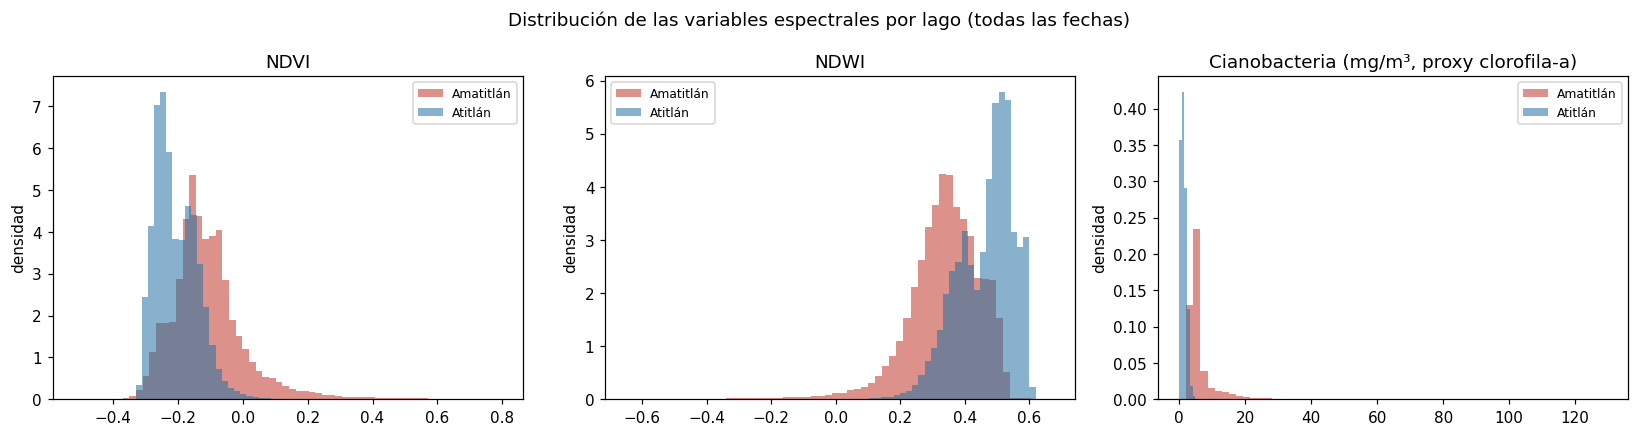

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, ax, title in zip(
    ["ndvi", "ndwi", "cyano_mg_m3"],
    axes,
    ["NDVI", "NDWI", "Cianobacteria (mg/m³, proxy clorofila-a)"],
):
    for lake_key, group in df_pixels.groupby("lake", observed=True):
        ax.hist(
            group[col].dropna(),
            bins=60,
            density=True,
            alpha=0.55,
            color=LAKE_COLORS[lake_key],
            label=LAKE_LABELS[lake_key],
        )
    ax.set_title(title)
    ax.set_ylabel("densidad")
    ax.legend(fontsize=8)
fig.suptitle("Distribución de las variables espectrales por lago (todas las fechas)")
fig.tight_layout()
plt.show()

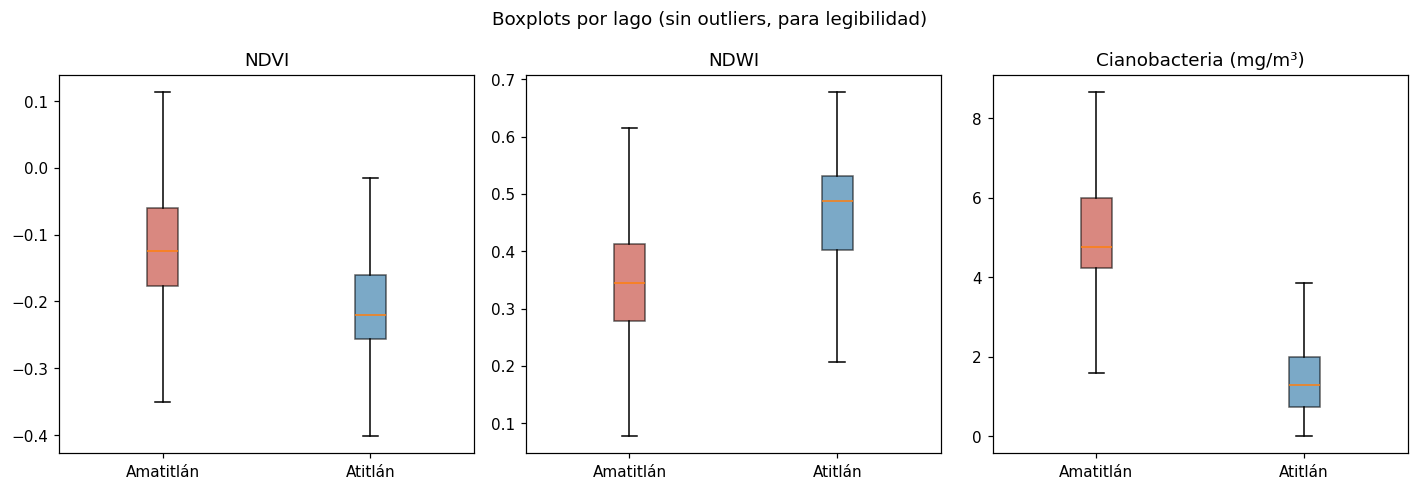

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for col, ax, title in zip(
    ["ndvi", "ndwi", "cyano_mg_m3"],
    axes,
    ["NDVI", "NDWI", "Cianobacteria (mg/m³)"],
):
    data = [df_pixels.loc[df_pixels["lake"] == lk, col].dropna() for lk in LAKES]
    bp = ax.boxplot(data, tick_labels=[LAKE_LABELS[lk] for lk in LAKES], showfliers=False, patch_artist=True)
    for patch, lk in zip(bp["boxes"], LAKES):
        patch.set_facecolor(LAKE_COLORS[lk])
        patch.set_alpha(0.6)
    ax.set_title(title)
fig.suptitle("Boxplots por lago (sin outliers, para legibilidad)")
fig.tight_layout()
plt.show()

In [7]:
print("Correlación de Pearson entre variables espectrales (pooled, ambos lagos):")
display(df_pixels[["ndvi", "ndwi", "cyano_mg_m3"]].corr())

print("\nPor lago:")
for lake_key, group in df_pixels.groupby("lake", observed=True):
    print(f"\n{LAKE_LABELS[lake_key]}:")
    display(group[["ndvi", "ndwi", "cyano_mg_m3"]].corr())

Correlación de Pearson entre variables espectrales (pooled, ambos lagos):


,ndvi,ndwi,cyano_mg_m3
ndvi,1.000000,-0.945589,0.725112
ndwi,-0.945589,1.000000,-0.659070
cyano_mg_m3,0.725112,-0.659070,1.000000



Por lago:



Amatitlán:

,ndvi,ndwi,cyano_mg_m3
ndvi,1.000000,-0.938791,0.768798
ndwi,-0.938791,1.000000,-0.636871
cyano_mg_m3,0.768798,-0.636871,1.000000



Atitlán:


,ndvi,ndwi,cyano_mg_m3
ndvi,1.000000,-0.944542,0.770163
ndwi,-0.944542,1.000000,-0.795698
cyano_mg_m3,0.770163,-0.795698,1.000000


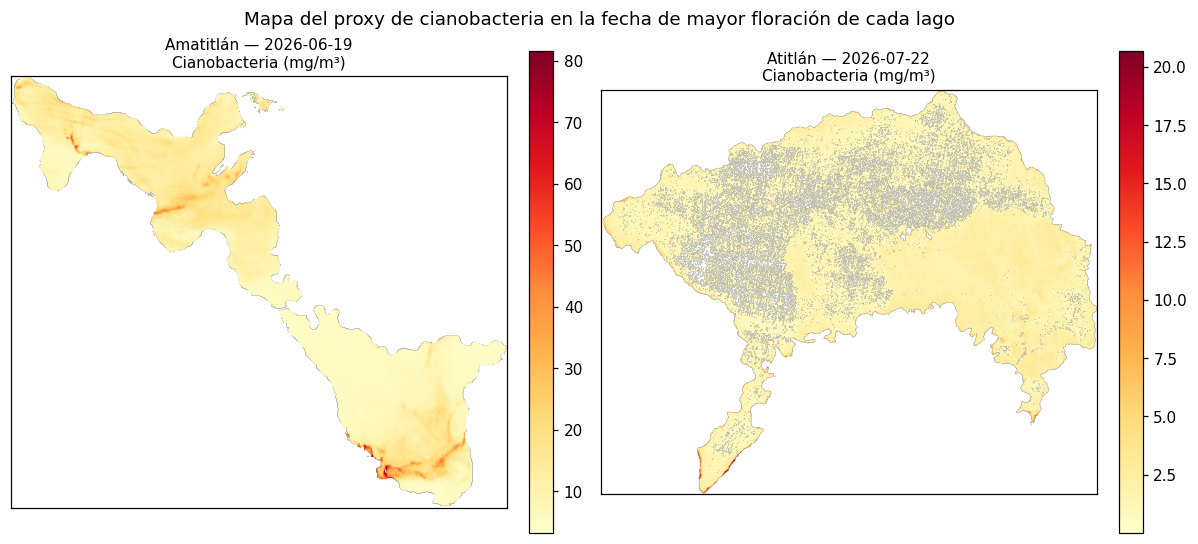

In [8]:
def plot_index_map(ax, lake_key, date, band_path, cmap, title):
    with rasterio.open(PROCESSED_DIR / lake_key / date / band_path) as ds:
        arr = ds.read(1, masked=True)
    im = ax.imshow(arr, cmap=cmap)
    ax.set_title(f"{LAKE_LABELS[lake_key]} — {date}\n{title}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Fecha más nublada/normal vs. fecha con mayor proporción de alta cianobacteria por lago
peak_dates = {
    "amatitlan": "2026-06-19",  # pico de floración detectado en la Parte I
    "atitlan": "2026-07-22",
}
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (lake_key, date) in zip(axes, peak_dates.items()):
    plot_index_map(ax, lake_key, date, "cyanobacteria.tif", "YlOrRd", "Cianobacteria (mg/m³)")
fig.suptitle("Mapa del proxy de cianobacteria en la fecha de mayor floración de cada lago")
fig.tight_layout()
plt.show()

**Lectura del EDA:** el proxy de cianobacteria tiene una distribución claramente
asimétrica a la derecha en ambos lagos (la mayoría de los píxeles están cerca del
nivel base del lago, con una cola larga de valores altos en fechas/zonas de
floración). Amatitlán tiene sistemáticamente valores de cianobacteria más altos y más
dispersos que Atitlán (consistente con que Amatitlán es un lago hipereutrófico y
Atitlán es comparativamente oligo-mesotrófico, como ya se había documentado en la
Parte I). El NDVI es negativo en la gran mayoría de los píxeles de agua abierta (como
se espera físicamente: el rojo refleja más que el infrarrojo cercano sobre agua), y el
NDWI es positivo, también como se espera sobre superficies de agua. La correlación
entre NDVI/NDWI y el proxy de cianobacteria es más fuerte en Amatitlán que en
Atitlán, lo cual es razonable porque en Amatitlán las floraciones cubren una fracción
mucho mayor de la superficie del lago y generan más contraste espectral.

### 1.6. Decisiones tomadas durante la preparación y limpieza de los datos

- **Unidad de observación = píxel válido de una grilla lago/fecha**, no un promedio
  por fecha: se necesita resolución espacial para los ejercicios 6 (validación
  espacial) y 9 (mapas predictivos) de la entrega final.
- **Sin bandas espectrales crudas como columnas**, porque la Parte I no las
  persistió individualmente (ver nota en 1.1–1.3); se usan NDVI, NDWI y el proxy de
  cianobacteria, que sí están disponibles píxel a píxel.
- **Criterio de validez idéntico al de la Parte I** (máscara de agua oficial ∩ NDVI,
  NDWI y cianobacteria finitos), en vez de definir un filtro nuevo, para que el
  número de observaciones por fecha coincida exactamente con `valid_pixels` de
  `outputs/quality_metrics.csv` y el dataset sea auditable contra la Parte I.
- **Se guardan ambos sistemas de coordenadas** (UTM 15N en metros, para cálculos de
  distancia y para la validación espacial de la entrega final; lon/lat en WGS84, para
  mapas legibles).
- **Formato de almacenamiento:** el dataset se guarda como Parquet
  (`outputs/ml_pixel_dataset.parquet`) en lugar de CSV — son cerca de 2.8 millones de
  filas y Parquet es sustancialmente más compacto y rápido de releer.

## 2. Ejercicio 2 — Construcción de la variable respuesta

### 2.1–2.2. Variable binaria y justificación del punto de corte

Se define `high_cyano = 1` si el proxy de cianobacteria (`cyano_mg_m3`, en mg/m³,
numéricamente equivalente a µg/L de clorofila-a según la nota de radiometría de la
Parte I) es mayor o igual a un umbral, y `0` en caso contrario.

**Umbral usado: 10 µg/L de clorofila-a.** Corresponde al **Alert Level 1** de la guía
de la Organización Mundial de la Salud para aguas recreativas con floraciones de
cianobacterias (Chorus & Bartram, 1999, *Toxic Cyanobacteria in Water*; WHO, 2003,
*Guidelines for Safe Recreational Water Environments*, Vol. 1, cap. 8 — la edición
2021 de la guía de calidad del agua para uso recreativo de la OMS mantiene el mismo
orden de magnitud). Ese nivel se definió, desde el punto de vista ambiental y de
salud pública, como el punto en el que aumenta de forma apreciable la probabilidad de
efectos adversos leves (irritación de piel/mucosas) en contacto recreativo con el
agua, y es el punto en el que las guías recomiendan iniciar monitoreo reforzado y
comunicación de riesgo. Por debajo de ese nivel se considera baja probabilidad de
efectos adversos ("vigilancia"); el Alert Level 2 (≈50 µg/L, asociado a acumulación
visible de cianobacterias / *scum*) ya implica restringir el contacto recreativo. Se
usa el Alert Level 1 porque es el corte más conservador desde el punto de vista de
salud pública (una autoridad de monitoreo preferiría un falso positivo — investigar
una zona que en realidad está bien — a un falso negativo que deje pasar una zona con
riesgo real; ver también la discusión de costos de error del Ejercicio 5.3 en la
entrega final).

In [9]:
df_resp = add_response_variable(df_pixels, threshold_ug_l=WHO_ALERT_LEVEL_1_UG_L)
print(f"Umbral usado: {WHO_ALERT_LEVEL_1_UG_L} µg/L (µg/L ≈ mg/m³ en este proxy)")
print("\nDistribución global de la variable respuesta:")
display(df_resp[RESPONSE_COLUMN].value_counts(normalize=True).rename("proporción").to_frame())

Umbral usado: 10.0 µg/L (µg/L ≈ mg/m³ en este proxy)

Distribución global de la variable respuesta:


,proporción
high_cyano,
0,0.985039
1,0.014961


### 2.3. Distribución de la variable respuesta por lago y por fecha

In [10]:
by_lake = df_resp.groupby("lake", observed=True)[RESPONSE_COLUMN].mean().rename("proporción_alta_cianobacteria")
display(by_lake.to_frame())

by_lake_date = (
    df_resp.groupby(["lake", "date"], observed=True)[RESPONSE_COLUMN]
    .agg(n="size", proporcion="mean")
    .reset_index()
)
display(by_lake_date)

,proporción_alta_cianobacteria
lake,
amatitlan,0.105903
atitlan,0.000216


,lake,date,n,proporcion
0,amatitlan,2025-01-28,35983,0.000000
1,amatitlan,2025-04-15,35527,0.005095
2,amatitlan,2025-04-28,35460,0.068246
3,amatitlan,2025-11-24,35929,0.019928
4,amatitlan,2026-01-08,35759,0.070304
5,amatitlan,2026-02-02,34291,0.000000
6,amatitlan,2026-02-07,35938,0.000056
7,amatitlan,2026-03-29,35870,0.075077
8,amatitlan,2026-04-13,36034,0.037603
9,amatitlan,2026-04-28,33649,0.362418


C:\Users\ianro\AppData\Local\Temp\ipykernel_19452\1818736433.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for lake_key, group in by_lake_date.groupby("lake"):


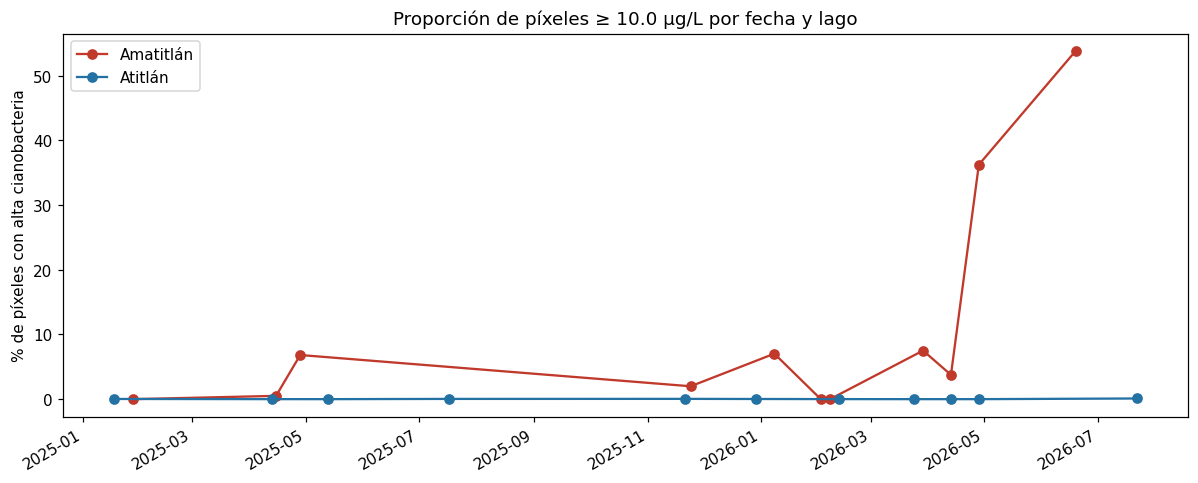

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for lake_key, group in by_lake_date.groupby("lake"):
    ax.plot(
        group["date"], group["proporcion"] * 100, marker="o",
        color=LAKE_COLORS[lake_key], label=LAKE_LABELS[lake_key],
    )
ax.set_ylabel("% de píxeles con alta cianobacteria")
ax.set_title(f"Proporción de píxeles ≥ {WHO_ALERT_LEVEL_1_UG_L} µg/L por fecha y lago")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### 2.4. Desbalance de clases

La proporción global de `high_cyano = 1` es de apenas **1.5%** (2.8 millones de
observaciones, la gran mayoría de Atitlán). Pero ese número pooled esconde una
diferencia enorme entre lagos: en **Amatitlán, el 10.6%** de los píxeles válidos
supera el umbral (y hasta **53.8%** en la fecha de mayor floración, 2026-06-19),
mientras que en **Atitlán solo el 0.02%** lo hace. Es decir, hay dos fuentes de
desbalance superpuestas: (a) desbalance de clase dentro de cada lago (más marcado en
Atitlán) y (b) una distribución de clases radicalmente distinta entre lagos, lo cual
es exactamente el fenómeno que se investigará formalmente en el Ejercicio 7
(generalización entre lagos) de la entrega final.

**Consecuencias para entrenamiento y evaluación:**

- Un modelo entrenado con el dataset pooled, sin ajustes, tenderá a predecir casi
  siempre la clase mayoritaria (`0`) porque minimiza el error promedio haciéndolo; la
  **exactitud (accuracy)** puede superar el 98% con un modelo trivial que nunca
  predice `1`, y aun así ser inútil para el objetivo del laboratorio (detectar
  floraciones).
- Las métricas relevantes deben ser sensibles a la clase minoritaria: **Recall,
  Precision, F1-score y ROC-AUC / PR-AUC** en vez de solo accuracy (ver Ejercicio 5 de
  la entrega final).
- Puede ser necesario **ponderar clases** (`class_weight="balanced"`),
  **remuestrear** (submuestreo de la clase mayoritaria o sobremuestreo tipo SMOTE) o
  **entrenar y evaluar por separado por lago**, dado que agrupar ambos lagos en un
  solo modelo puede hacer que Atitlán (con casi cero positivos) domine la función de
  pérdida y que el modelo prácticamente ignore la señal de Amatitlán.
- La **división entrenamiento/prueba** (Ejercicio 4.2) deberá ser estratificada por
  `high_cyano` (y probablemente por `lake`) para garantizar que ambos conjuntos
  conserven una proporción de positivos representativa.

### 2.5. Variables que no pueden usarse como predictoras

La variable respuesta `high_cyano` se construye aplicando un corte directo sobre
`cyano_mg_m3`. Por lo tanto:

- **`cyano_mg_m3` debe excluirse de las variables predictoras**: es la variable
  continua de la cual `high_cyano` es una función determinística (un simple
  `>= umbral`); incluirla sería fuga de información total (el modelo "adivinaría" la
  respuesta con precisión perfecta sin aprender nada generalizable).
- Por la misma razón, si en el futuro se incorporan **NDCI** `(B05-B04)/(B05+B04)` o
  las **bandas B04/B05** individuales como columnas, tampoco podrían usarse como
  predictoras: `cyano_mg_m3` es una función cúbica determinística de NDCI
  (`chlorophyll_a = 826.57·NDCI³ − 176.43·NDCI² + 19·NDCI + 4.071`, script oficial de
  Sentinel Hub), y NDCI a su vez es una función determinística de B04 y B05. Ahora
  mismo esas columnas no están en el dataset (ver 1.1–1.3), pero queda documentado
  para si se agregan más adelante.
- **NDVI y NDWI sí se conservan como predictoras.** Aunque NDVI comparte la banda
  B04 con el cálculo de NDCI, NDVI y NDWI **no determinan** matemáticamente el valor
  de cianobacteria (son razones distintas, con B08/B03 de por medio) — la correlación
  observada en el EDA (1.5) es física/ecológica (vegetación, turbidez, profundidad),
  no una identidad algebraica, así que no constituyen fuga de información en el mismo
  sentido.

Esto se deja codificado explícitamente en `src/ml_dataset.RESPONSE_LEAKAGE_COLUMNS`.

In [12]:
print("Columnas excluidas de las variables predictoras (fuga de información):")
print(RESPONSE_LEAKAGE_COLUMNS)

Columnas excluidas de las variables predictoras (fuga de información):
('cyano_mg_m3',)


## 3. Ejercicio 3 — Selección y construcción de variables predictoras

### 3.1–3.2. Conjunto de variables predictoras

In [13]:
predictor_table = pd.DataFrame(
    [
        ("ndvi", "Índice de vegetación de diferencia normalizada, (B08-B04)/(B08+B04)",
         "Índice espectral", "Sensible a vegetación/algas flotantes y a turbidez del agua; "
         "valores menos negativos suelen acompañar mayor actividad fotosintética/algal."),
        ("ndwi", "Índice de agua de diferencia normalizada, (B03-B08)/(B03+B08)",
         "Índice espectral", "Delimita agua vs. no-agua y responde a turbidez/materia en "
         "suspensión, que suele acompañar floraciones."),
        ("lake", "Lago de origen de la observación (Amatitlán / Atitlán)",
         "Característica categórica", "Los dos lagos tienen regímenes tróficos muy distintos "
         "(ver 2.4); el modelo necesita saber en cuál lago está parado cada píxel."),
        ("month", "Mes calendario de la fecha de adquisición (1-12)",
         "Característica temporal", "La Parte I encontró estacionalidad en las floraciones "
         "(picos hacia fin de época seca / inicio de lluvias); captura ese ciclo."),
        ("day_of_year", "Día del año (1-366) de la fecha de adquisición",
         "Característica temporal", "Versión continua de la estacionalidad, útil si la relación "
         "con el tiempo del año no es puramente mensual."),
        ("dist_centroid_m", "Distancia euclidiana (m) al centroide del polígono del lago, en EPSG:32615",
         "Característica espacial derivada", "Proxy simple de zona litoral/costera vs. zona "
         "central del lago; las orillas suelen recibir más aporte de nutrientes (escorrentía, "
         "aguas residuales) y podrían concentrar más floraciones."),
    ],
    columns=["variable", "descripción", "tipo", "justificación"],
)
display(predictor_table)

,variable,descripción,tipo,justificación
0,ndvi,Índice de vegetación de diferencia normalizada...,Índice espectral,Sensible a vegetación/algas flotantes y a turb...
1,ndwi,"Índice de agua de diferencia normalizada, (B03...",Índice espectral,Delimita agua vs. no-agua y responde a turbide...
2,lake,Lago de origen de la observación (Amatitlán / ...,Característica categórica,Los dos lagos tienen regímenes tróficos muy di...
3,month,Mes calendario de la fecha de adquisición (1-12),Característica temporal,La Parte I encontró estacionalidad en las flor...
4,day_of_year,Día del año (1-366) de la fecha de adquisición,Característica temporal,"Versión continua de la estacionalidad, útil si..."
5,dist_centroid_m,Distancia euclidiana (m) al centroide del polí...,Característica espacial derivada,Proxy simple de zona litoral/costera vs. zona ...


**Coordenadas (`x_utm15n`, `y_utm15n`, `lon`, `lat`) y `date` se conservan en el
dataset pero *no* se usan directamente como variables predictoras.** Usar la posición
absoluta de un píxel como predictor le permitiría al modelo "memorizar" ubicaciones
específicas en lugar de aprender relaciones espectrales/temporales generalizables —
justo lo opuesto de lo que buscan los ejercicios 6 (validación espacial) y 7
(generalización entre lagos) de la entrega final. Se conservan como metadata: para
construir los bloques espaciales del Ejercicio 6, para reconstruir los mapas
predictivos del Ejercicio 9, y como llave para unir con variables externas (clima,
Ejercicio 10.3). El único derivado espacial que sí se usa como predictor es
`dist_centroid_m`, que es una distancia relativa (no una coordenada absoluta) y por lo
tanto sí generaliza entre lagos.

### 3.3. Ingeniería de características

In [14]:
centroids = lake_centroids_utm()
print("Centroide de cada lago (EPSG:32615):", centroids)

df_ready = engineer_features(df_resp, centroids)
new_cols = ["month", "day_of_year", "dist_centroid_m"]
display(df_ready[new_cols].describe())
df_ready[["lake", "date", "ndvi", "ndwi", "cyano_mg_m3", RESPONSE_COLUMN, *new_cols]].head()

Centroide de cada lago (EPSG:32615): {'amatitlan': (762298.3977291782, 1599667.9466894586), 'atitlan': (694380.5733085517, 1625425.530231374)}


,month,day_of_year,dist_centroid_m
count,2.796957e+06,2.796957e+06,2.796957e+06
mean,4.978504e+00,1.396295e+02,4.708428e+03
std,3.275966e+00,1.025964e+02,2.203572e+03
min,1.000000e+00,8.000000e+00,8.645111e+00
25%,3.000000e+00,8.300000e+01,3.041098e+03
50%,4.000000e+00,1.180000e+02,4.581675e+03
75%,7.000000e+00,2.030000e+02,6.256695e+03
max,1.200000e+01,3.630000e+02,1.113614e+04


,lake,date,ndvi,ndwi,cyano_mg_m3,high_cyano,month,day_of_year,dist_centroid_m
0,amatitlan,2025-01-28,0.000000,0.181387,4.672294,0,1,28,5923.766579
1,amatitlan,2025-01-28,0.030928,0.158878,4.861514,0,1,28,5908.220931
2,amatitlan,2025-01-28,0.012658,0.165877,4.681990,0,1,28,5877.210456
3,amatitlan,2025-01-28,-0.014599,0.194831,4.340311,0,1,28,5861.746057
4,amatitlan,2025-01-28,-0.062500,0.256198,4.611503,0,1,28,5958.115144


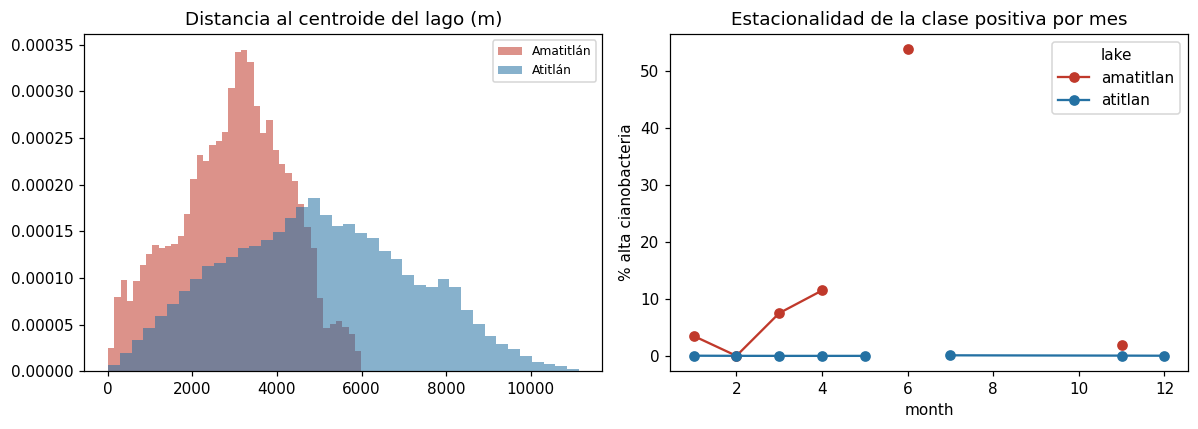

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for lake_key, group in df_ready.groupby("lake", observed=True):
    axes[0].hist(group["dist_centroid_m"], bins=40, alpha=0.55, density=True,
                 color=LAKE_COLORS[lake_key], label=LAKE_LABELS[lake_key])
axes[0].set_title("Distancia al centroide del lago (m)")
axes[0].legend(fontsize=8)

monthly = df_ready.groupby(["lake", "month"], observed=True)[RESPONSE_COLUMN].mean().unstack("lake") * 100
monthly.plot(ax=axes[1], marker="o", color=[LAKE_COLORS[c] for c in monthly.columns])
axes[1].set_ylabel("% alta cianobacteria")
axes[1].set_title("Estacionalidad de la clase positiva por mes")
fig.tight_layout()
plt.show()

In [16]:
predictors = ["ndvi", "ndwi", "lake", "month", "day_of_year", "dist_centroid_m"]
metadata_cols = ["x_utm15n", "y_utm15n", "lon", "lat", "date"]

final_columns = [*metadata_cols, *predictors, RESPONSE_COLUMN, *RESPONSE_LEAKAGE_COLUMNS]
df_final = df_ready[final_columns].copy()

save_ready_dataset(df_final)
print(f"Dataset final guardado en outputs/ml_dataset_ready.parquet — shape: {df_final.shape}")
print(f"\nPredictoras ({len(predictors)}): {predictors}")
print(f"Metadata (no predictoras): {metadata_cols}")
print(f"Respuesta: '{RESPONSE_COLUMN}' — excluida por fuga: {list(RESPONSE_LEAKAGE_COLUMNS)}")
df_final.head()

Dataset final guardado en outputs/ml_dataset_ready.parquet — shape: (2796957, 13)

Predictoras (6): ['ndvi', 'ndwi', 'lake', 'month', 'day_of_year', 'dist_centroid_m']
Metadata (no predictoras): ['x_utm15n', 'y_utm15n', 'lon', 'lat', 'date']
Respuesta: 'high_cyano' — excluida por fuga: ['cyano_mg_m3']


,x_utm15n,y_utm15n,lon,lat,date,ndvi,ndwi,lake,month,day_of_year,dist_centroid_m,high_cyano,cyano_mg_m3
0,757690.0,1603390.0,-90.609223,14.491131,2025-01-28,0.000000,0.181387,amatitlan,1,28,5923.766579,0,4.672294
1,757710.0,1603390.0,-90.609037,14.491130,2025-01-28,0.030928,0.158878,amatitlan,1,28,5908.220931,0,4.861514
2,757750.0,1603390.0,-90.608667,14.491126,2025-01-28,0.012658,0.165877,amatitlan,1,28,5877.210456,0,4.681990
3,757770.0,1603390.0,-90.608481,14.491124,2025-01-28,-0.014599,0.194831,amatitlan,1,28,5861.746057,0,4.340311
4,757630.0,1603370.0,-90.609781,14.490956,2025-01-28,-0.062500,0.256198,amatitlan,1,28,5958.115144,0,4.611503


## Próximos pasos (entrega final)

Este avance deja listo `outputs/ml_dataset_ready.parquet` (~2.8 millones de
observaciones, columnas de metadata + predictoras + respuesta + la variable de fuga
conservada solo para trazabilidad) como punto de partida para los ejercicios 4 a 10:
entrenamiento de Regresión Logística, Random Forest y Gradient Boosting/XGBoost
(Ej. 4), evaluación con métricas sensibles al desbalance (Ej. 5), validación espacial
por bloques de ~1 km² en EPSG:32615 (Ej. 6), generalización entrenando en un lago y
evaluando en el otro (Ej. 7), interpretabilidad con importancia de variables y SHAP
(Ej. 8), mapas predictivos de probabilidad (Ej. 9) y el análisis/conclusiones finales
(Ej. 10).